In [1]:
# use holodeck environment

In [1]:
# making sure the notebook is run from the right directory, as lots of paths are relative to the root directory
from pathlib import Path
PROJECT_ROOT = Path.cwd().parents[1]

if not (PROJECT_ROOT / 'holodeck_output_lib_gp_mcmc').exists():
    raise RuntimeError("Please run Jupyter from the notebooks_and_files_for_final_results directory")


In [3]:
import holodeck as holo
import holodeck
from holodeck.constants import YR, NWTG, SPLC, GYR, PC, MSOL
from holodeck.galaxy_profiles import NFW
from holodeck import utils
from holodeck.librarian import DEF_NUM_FBINS, DEF_NUM_LOUDEST, DEF_PTA_DUR
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar
from scipy.integrate import solve_ivp, quad
import numpy as np
import kalepy as kale
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
import os
import la_forge.core as co
from ceffyl.chain_utils import chain_utils
import la_forge.diagnostics as dg
from chainconsumer.chainconsumer import ChainConsumer
from emcee.autocorr import integrated_time

import numpy as np
import matplotlib.pyplot as plt

PINT not installed. PINT or libstempo are required to use par and tim files.


# Stats analysis

## comparing posteriors for 2k, 4k, 8k trained GP mcmc

for n_training:8000, mtot_array: [5.44e+09 2.40e+09 1.59e+09 1.06e+09 1.44e+07]
data.shape (97400, 20)
the chain is taken from the path: freq_bin0_mtot_5.44e+09_mrat_0.96_redz_1.05
updated chain length: (50296, 6)

for n_training:4000, mtot_array: [4.43e+09 2.17e+07 2.17e+07 6.03e+07 6.03e+07]
data.shape (123090, 20)
the chain is taken from the path: freq_bin0_mtot_4.43e+09_mrat_0.96_redz_0.87
updated chain length: (62445, 6)

for n_training:2000, mtot_array: [4.43e+09 2.40e+09 1.30e+09 1.76e+07 5.73e+08]
data.shape (100000, 20)
the chain is taken from the path: freq_bin0_mtot_4.43e+09_mrat_0.88_redz_0.80
updated chain length: (49612, 6)


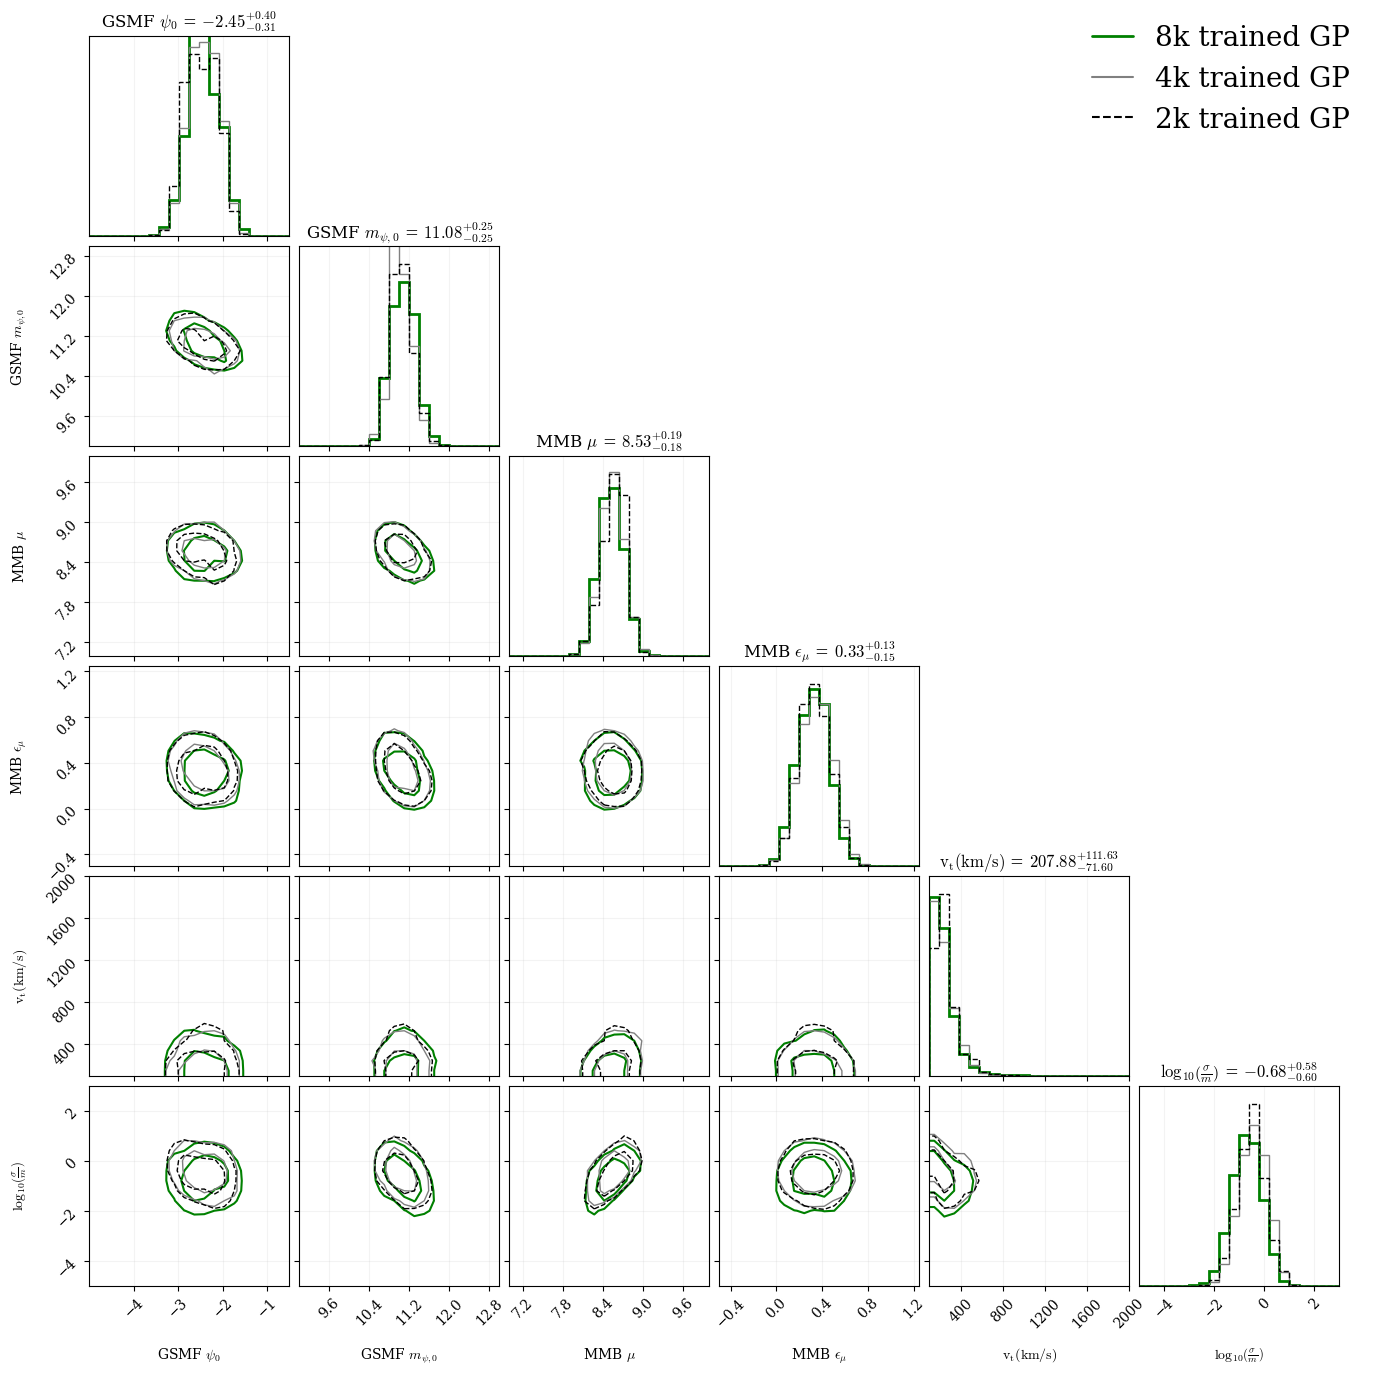

In [4]:
gp_nn = 'gp'

PARAM_SPACE = 'PS_Classic_SIDM_Astro_Extended_Version2'
NSAMPLES = 8000
NREALS = 2000
NFREQS = 5
NFREQS_TRAINING = 5 # for gp training and ceffyl mcmc

# correct prior implementation
OUTPUT = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/SIDM_Astro_Uniform_Extended_Version2_n{NSAMPLES}_r{NREALS}_f{NFREQS}/library'

# hd_mp_dp_curn_path = Path(OUTPUT).parent / 'gp_mcmc_log_likelihood_all_freqs' / 'ceffyl_output_hd_mp_dp_curn'
hd_mp_dp_curn_path = Path(OUTPUT).parent / f'{gp_nn}_mcmc_log_likelihood_all_freqs' / 'ceffyl_output_hd_mp_dp_curn'

max_contri_mqz_5_freqs_dict_path = hd_mp_dp_curn_path / 'stats_analysis' / 'max_contri_mqz_5_freqs_dict.npz'

# to have paths of all chains for max contri mqz

max_contri_mqz_5_freqs_dict = np.load(max_contri_mqz_5_freqs_dict_path)
mtot_array = max_contri_mqz_5_freqs_dict["mtot_array"]
mrat_array = max_contri_mqz_5_freqs_dict["mrat_array"]
redz_array = max_contri_mqz_5_freqs_dict["redz_array"]
print(
    f'for n_training:{NSAMPLES}, mtot_array: '
    f'{np.array2string(mtot_array, formatter={"float_kind": lambda x: f"{x:.2e}"})}'
)
path_list = []
for i in range(len(mtot_array)):
    mtot = mtot_array[i] * MSOL
    mrat = mrat_array[i]
    redz = redz_array[i]
    new_path_to_updated_txt_file =Path(max_contri_mqz_5_freqs_dict_path).parent / f'freq_bin{i}_mtot_{(mtot/MSOL):.2e}_mrat_{mrat:.2f}_redz_{redz:.2f}/updated_chain_1_with_sigma_over_m.txt'

    path_list.append(new_path_to_updated_txt_file) 

path_list
updated_chain_path = path_list[0]
# updated_chain_path = path_list[-1]
data = np.loadtxt(updated_chain_path)
print(f'data.shape {data.shape}')
print(f'the chain is taken from the path: {updated_chain_path.parent.name}')
# to apply grey region exclusion from acd fig.4 (sigma0/m * t_age/1GYR > 0.25) and (tdf > 50 Myr) and (tdf < 13.79 Gyrs)
idx = np.where((data[:, 5] > 0.25) & (data[:, 7]/(50*1e6*YR) > 1.0) & (data[:, 7]/GYR < 13.79))

# for no constraints
# idx = np.where(data[:, 5] > 0)


import corner
import numpy as np
import matplotlib.pyplot as plt
# index 0 - psi0
# index 1 - gsmf_mchar0_log10
# index 2 - mmb_mamp_log10
# index 3 - mmb_scatter_dex
# index 4 - vt
# index 5 - sigma0_over_m_times_t_age_by_1Gyr
# index 6 - sigma0_over_m
# index 7 - tdf
# index 8 - sigma_over_m
# index 9 - y
# index 10 - v0

# corner with selected params
data_copy_8k = data.copy()
data_copy_8k = data_copy_8k[idx[0], :]
data_copy_8k[:, 8] = np.log10(data_copy_8k[:, 8]) # for sigma/m
data_copy_8k = data_copy_8k[:, [0, 1, 2, 3, 4, 8]]

print(f'updated chain length: {data_copy_8k.shape}')
# print(f'path to updated mcmc chain: {updated_chain_path}')

##############################################################
NSAMPLES = 4000
# correct prior implementation
OUTPUT = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/SIDM_Astro_Uniform_Extended_Version2_n{NSAMPLES}_r{NREALS}_f{NFREQS}/library'
hd_mp_dp_curn_path = Path(OUTPUT).parent / f'{gp_nn}_mcmc_log_likelihood_all_freqs' / 'ceffyl_output_hd_mp_dp_curn'
max_contri_mqz_5_freqs_dict_path = hd_mp_dp_curn_path / 'stats_analysis' / 'max_contri_mqz_5_freqs_dict.npz'
# to have paths of all chains for max contri mqz
max_contri_mqz_5_freqs_dict = np.load(max_contri_mqz_5_freqs_dict_path)
mtot_array = max_contri_mqz_5_freqs_dict["mtot_array"]
mrat_array = max_contri_mqz_5_freqs_dict["mrat_array"]
redz_array = max_contri_mqz_5_freqs_dict["redz_array"]
print(
    f'\nfor n_training:{NSAMPLES}, mtot_array: '
    f'{np.array2string(mtot_array, formatter={"float_kind": lambda x: f"{x:.2e}"})}'
)
path_list = []
for i in range(len(mtot_array)):
    mtot = mtot_array[i] * MSOL
    mrat = mrat_array[i]
    redz = redz_array[i]
    new_path_to_updated_txt_file =Path(max_contri_mqz_5_freqs_dict_path).parent / f'freq_bin{i}_mtot_{(mtot/MSOL):.2e}_mrat_{mrat:.2f}_redz_{redz:.2f}/updated_chain_1_with_sigma_over_m.txt'
    path_list.append(new_path_to_updated_txt_file) 
updated_chain_path = path_list[0]
data = np.loadtxt(updated_chain_path)
print(f'data.shape {data.shape}')
print(f'the chain is taken from the path: {updated_chain_path.parent.name}')
# to apply grey region exclusion from acd fig.4 (sigma0/m * t_age/1GYR > 0.25) and (tdf > 50 Myr) and (tdf < 13.79 Gyrs)
idx = np.where((data[:, 5] > 0.25) & (data[:, 7]/(50*1e6*YR) > 1.0) & (data[:, 7]/GYR < 13.79))
data_copy_4k = data.copy()
data_copy_4k = data_copy_4k[idx[0], :]
data_copy_4k[:, 8] = np.log10(data_copy_4k[:, 8]) # for sigma/m
data_copy_4k = data_copy_4k[:, [0, 1, 2, 3, 4, 8]]
print(f'updated chain length: {data_copy_4k.shape}')

##############################################################
NSAMPLES = 2000
# correct prior implementation
OUTPUT = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/SIDM_Astro_Uniform_Extended_Version2_n{NSAMPLES}_r{NREALS}_f{NFREQS}/library'
hd_mp_dp_curn_path = Path(OUTPUT).parent / f'{gp_nn}_mcmc_log_likelihood_all_freqs' / 'ceffyl_output_hd_mp_dp_curn'
max_contri_mqz_5_freqs_dict_path = hd_mp_dp_curn_path / 'stats_analysis' / 'max_contri_mqz_5_freqs_dict.npz'
# to have paths of all chains for max contri mqz
max_contri_mqz_5_freqs_dict = np.load(max_contri_mqz_5_freqs_dict_path)
mtot_array = max_contri_mqz_5_freqs_dict["mtot_array"]
mrat_array = max_contri_mqz_5_freqs_dict["mrat_array"]
redz_array = max_contri_mqz_5_freqs_dict["redz_array"]
print(
    f'\nfor n_training:{NSAMPLES}, mtot_array: '
    f'{np.array2string(mtot_array, formatter={"float_kind": lambda x: f"{x:.2e}"})}'
)
path_list = []
for i in range(len(mtot_array)):
    mtot = mtot_array[i] * MSOL
    mrat = mrat_array[i]
    redz = redz_array[i]
    new_path_to_updated_txt_file =Path(max_contri_mqz_5_freqs_dict_path).parent / f'freq_bin{i}_mtot_{(mtot/MSOL):.2e}_mrat_{mrat:.2f}_redz_{redz:.2f}/updated_chain_1_with_sigma_over_m.txt'
    path_list.append(new_path_to_updated_txt_file) 
updated_chain_path = path_list[0]
data = np.loadtxt(updated_chain_path)
print(f'data.shape {data.shape}')
print(f'the chain is taken from the path: {updated_chain_path.parent.name}')
# to apply grey region exclusion from acd fig.4 (sigma0/m * t_age/1GYR > 0.25) and (tdf > 50 Myr) and (tdf < 13.79 Gyrs)
idx = np.where((data[:, 5] > 0.25) & (data[:, 7]/(50*1e6*YR) > 1.0) & (data[:, 7]/GYR < 13.79))
data_copy_2k = data.copy()
data_copy_2k = data_copy_2k[idx[0], :]
data_copy_2k[:, 8] = np.log10(data_copy_2k[:, 8]) # for sigma/m
data_copy_2k = data_copy_2k[:, [0, 1, 2, 3, 4, 8]]
print(f'updated chain length: {data_copy_2k.shape}')



labels = [r"GSMF $\psi_0$", r"GSMF $m_{\psi, 0}$", r"MMB $\mu$", r"MMB $\epsilon_{\mu}$", r"$\mathrm{v_t (km/s)}$", r"$\mathrm{log}_{10} \left( \frac{\sigma}{m} \right)$"]

# Define x-axis limits
ranges = [(-5, -0.5), (9, 13), (7, 10), (-0.5, 1.25), (100, 2000), (-5, 3)] # changed the lower limit on vt chain from 0 to 100 to avoid the edge effect (29.10.2025)
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# First (8k) — filled green
fig = corner.corner(
    data_copy_8k,
    labels=labels,
    range=ranges,
    show_titles=True,
    fill_contours=False,
    plot_contours=True,
    plot_density=False,
    plot_datapoints=False,
    levels=[0.68, 0.95],
    color='green',
    hist_kwargs={
        "linestyle": "-",
        "linewidth": 2,
        "density": True
    }
)

# Second (4k) — solid grey
corner.corner(
    data_copy_4k,
    fig=fig,
    range=ranges,
    plot_contours=True,
    plot_density=False,
    fill_contours=False,
    plot_datapoints=False,
    levels=[0.68, 0.95],
    color='grey',
    contour_kwargs={
        "linestyles": "solid",
        "linewidths": 1
    },
    hist_kwargs={
        "linestyle": "-",
        "linewidth":1,
        "density": True
    }
)

# Third (2k) — dashed black
corner.corner(
    data_copy_2k,
    fig=fig,
    range=ranges,
    plot_contours=True,
    plot_density=False,
    fill_contours=False,
    plot_datapoints=False,
    levels=[0.68, 0.95],
    color='black',
    contour_kwargs={
        "linestyles": "dashed",
        "linewidths": 1
    },
    hist_kwargs={
        "linestyle": "--",
        "linewidth": 1,
        "density": True
    }
)

if gp_nn=='gp':
    gp_nn_plt='GP'
else:
    gp_nn_plt='NN'

legend_elements = [
    Line2D([0], [0], color='green', lw=2, label=f'8k trained {gp_nn_plt}'),
    Line2D([0], [0], color='grey', lw=1.5, linestyle='-', label=f'4k trained {gp_nn_plt}'),
    Line2D([0], [0], color='black', lw=1.5, linestyle='--', label=f'2k trained {gp_nn_plt}')
]

fig.legend(
    handles=legend_elements,
    loc='upper right',
    fontsize=20,
    frameon=False
)

plt.show()


# Table of median and +- 1 sigma values

In [5]:
import pandas as pd
data_copy_array = [data_copy_8k, data_copy_4k, data_copy_2k]
dataset_labels = ["8k", "4k", "2k"]
param_labels = ['psi0', 'm_psi,0', 'mu', 'epsilon_mu', 'v_t', 'log10(sigma/m)']

rows = []

for label, data_copy in zip(dataset_labels, data_copy_array):
    for ii, pname in enumerate(param_labels):
        median = np.median(data_copy[:, ii])
        p16 = np.percentile(data_copy[:, ii], 16)
        p84 = np.percentile(data_copy[:, ii], 84)

        plus = p84 - median
        minus = median - p16

        formatted = f"{median:.2f}^{{+{plus:.2f}}}_{{-{minus:.2f}}}"

        rows.append({
            "Dataset": label,
            "Parameter": pname,
            "Median^+sigma_-sigma": formatted
        })

df_compact = pd.DataFrame(rows)
for i, label in enumerate(dataset_labels):
    subset = df_compact[df_compact["Dataset"] == label].drop(columns=["Dataset"])
    
    print(f"Dataset: {label}")
    print(subset.to_string(index=False))
    
    if i < len(dataset_labels) - 1:
        print("\n" + "-" * 50 + "\n")


Dataset: 8k
     Parameter      Median^+sigma_-sigma
          psi0     -2.45^{+0.40}_{-0.31}
       m_psi,0     11.08^{+0.25}_{-0.25}
            mu      8.53^{+0.19}_{-0.18}
    epsilon_mu      0.33^{+0.13}_{-0.15}
           v_t 207.88^{+111.63}_{-71.60}
log10(sigma/m)     -0.68^{+0.58}_{-0.60}

--------------------------------------------------

Dataset: 4k
     Parameter      Median^+sigma_-sigma
          psi0     -2.42^{+0.36}_{-0.35}
       m_psi,0     11.02^{+0.25}_{-0.16}
            mu      8.55^{+0.18}_{-0.17}
    epsilon_mu      0.35^{+0.14}_{-0.15}
           v_t 211.33^{+133.17}_{-83.19}
log10(sigma/m)     -0.42^{+0.56}_{-0.58}

--------------------------------------------------

Dataset: 2k
     Parameter      Median^+sigma_-sigma
          psi0     -2.47^{+0.39}_{-0.37}
       m_psi,0     11.03^{+0.24}_{-0.21}
            mu      8.59^{+0.14}_{-0.20}
    epsilon_mu      0.33^{+0.14}_{-0.13}
           v_t 235.88^{+100.55}_{-80.83}
log10(sigma/m)     -0.49^{+0.53}_{-0.5

## comparing posteriors for 2k, 4k, 8k trained NN mcmc

for n_training:8000, mtot_array: [6.68e+09 3.61e+09 1.96e+09 1.59e+09 1.06e+09]
data.shape (127744, 20)
the chain is taken from the path: freq_bin4_mtot_1.06e+09_mrat_0.88_redz_0.80
updated chain length: (56856, 6)

for n_training:4000, mtot_array: [3.80e+08 1.68e+08 1.68e+08 4.91e+07 1.68e+08]
data.shape (113900, 20)
the chain is taken from the path: freq_bin0_mtot_3.80e+08_mrat_0.11_redz_0.87
updated chain length: (35365, 6)

for n_training:2000, mtot_array: [3.10e+08 1.37e+08 1.68e+08 3.10e+08 2.53e+08]
data.shape (130000, 20)
the chain is taken from the path: freq_bin0_mtot_3.10e+08_mrat_0.44_redz_0.73
updated chain length: (50522, 6)


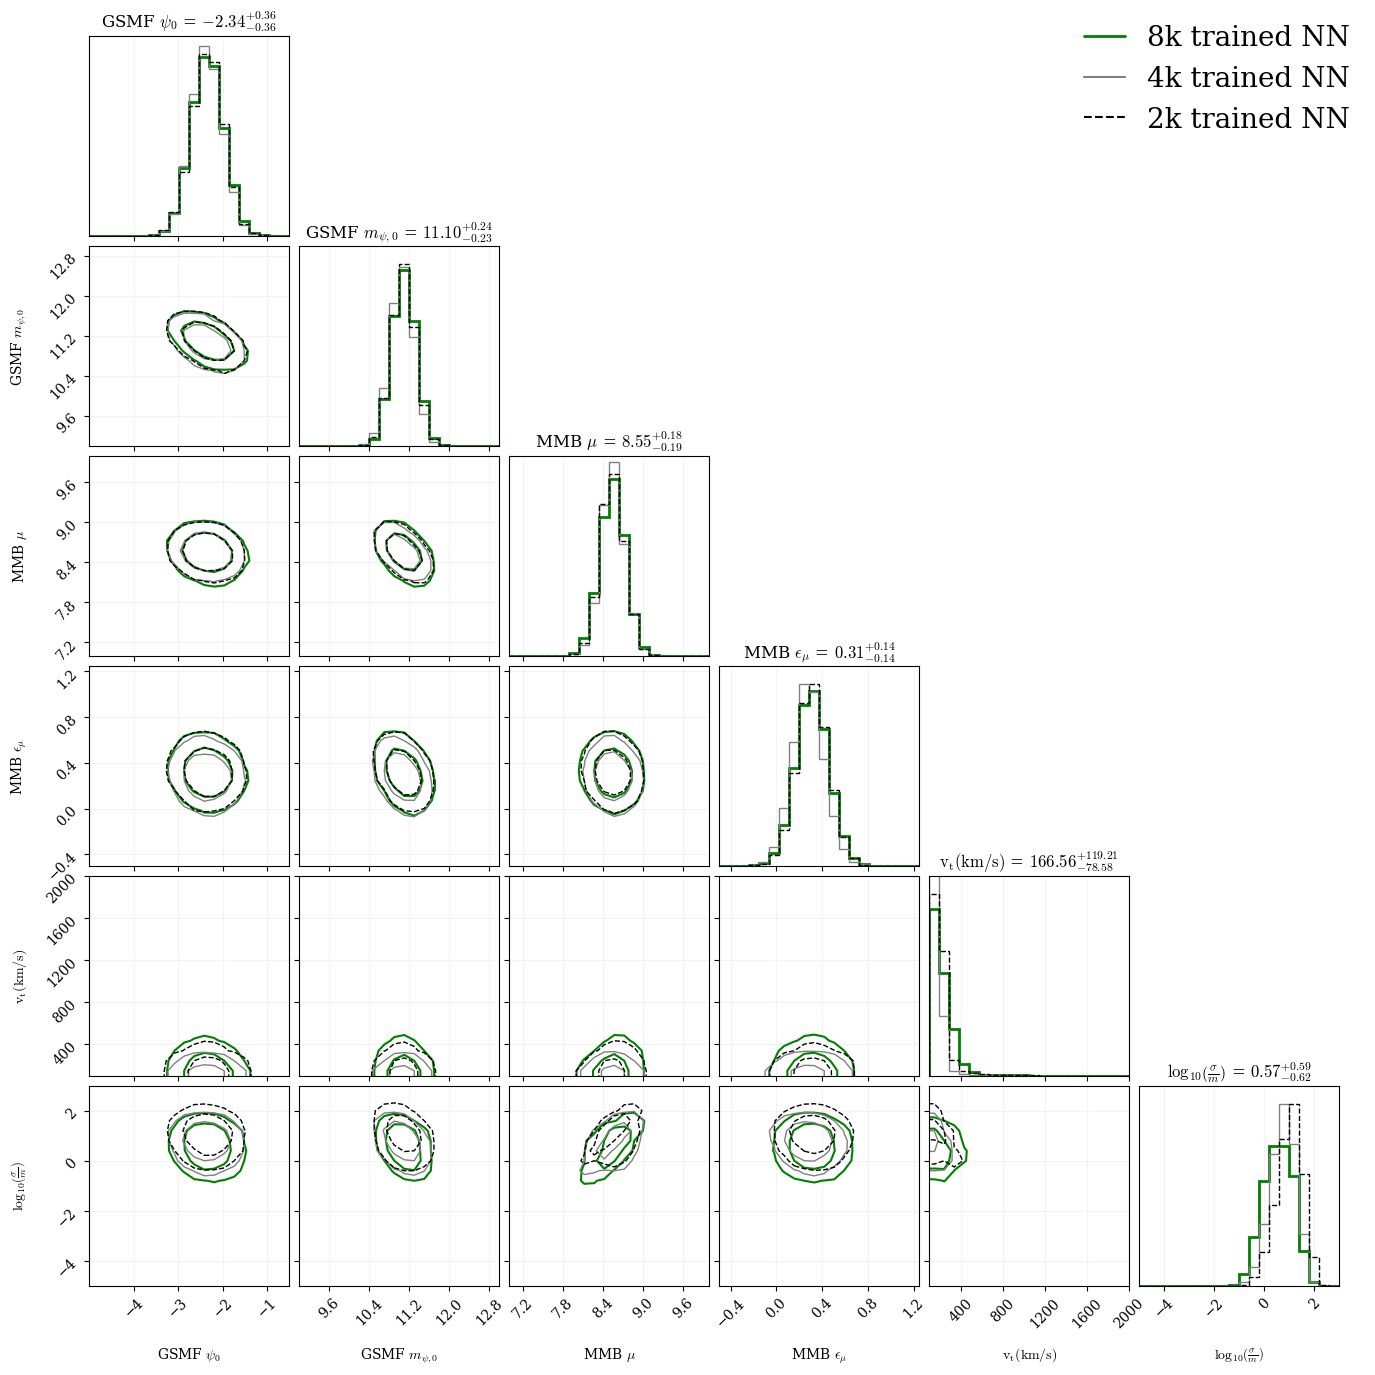

In [6]:
gp_nn = 'nn'

PARAM_SPACE = 'PS_Classic_SIDM_Astro_Extended_Version2'
NSAMPLES = 8000
NREALS = 2000
NFREQS = 5
NFREQS_TRAINING = 5 # for gp training and ceffyl mcmc

# correct prior implementation
OUTPUT = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/SIDM_Astro_Uniform_Extended_Version2_n{NSAMPLES}_r{NREALS}_f{NFREQS}/library'

hd_mp_dp_curn_path = Path(OUTPUT).parent / f'{gp_nn}_mcmc_log_likelihood_all_freqs' / 'ceffyl_output_hd_mp_dp_curn'

max_contri_mqz_5_freqs_dict_path = hd_mp_dp_curn_path / 'stats_analysis' / 'max_contri_mqz_5_freqs_dict.npz'

# to have paths of all chains for max contri mqz

max_contri_mqz_5_freqs_dict = np.load(max_contri_mqz_5_freqs_dict_path)
mtot_array = max_contri_mqz_5_freqs_dict["mtot_array"]
mrat_array = max_contri_mqz_5_freqs_dict["mrat_array"]
redz_array = max_contri_mqz_5_freqs_dict["redz_array"]
print(
    f'for n_training:{NSAMPLES}, mtot_array: '
    f'{np.array2string(mtot_array, formatter={"float_kind": lambda x: f"{x:.2e}"})}'
)
path_list = []
for i in range(len(mtot_array)):
    mtot = mtot_array[i] * MSOL
    mrat = mrat_array[i]
    redz = redz_array[i]
    new_path_to_updated_txt_file =Path(max_contri_mqz_5_freqs_dict_path).parent / f'freq_bin{i}_mtot_{(mtot/MSOL):.2e}_mrat_{mrat:.2f}_redz_{redz:.2f}/updated_chain_1_with_sigma_over_m.txt'

    path_list.append(new_path_to_updated_txt_file) 

path_list
# updated_chain_path = path_list[0]
updated_chain_path = path_list[-1]
data = np.loadtxt(updated_chain_path)
print(f'data.shape {data.shape}')
print(f'the chain is taken from the path: {updated_chain_path.parent.name}')
# to apply grey region exclusion from acd fig.4 (sigma0/m * t_age/1GYR > 0.25) and (tdf > 50 Myr) and (tdf < 13.79 Gyrs)
idx = np.where((data[:, 5] > 0.25) & (data[:, 7]/(50*1e6*YR) > 1.0) & (data[:, 7]/GYR < 13.79))

# for no constraints
# idx = np.where(data[:, 5] > 0)


import corner
import numpy as np
import matplotlib.pyplot as plt
# index 0 - psi0
# index 1 - gsmf_mchar0_log10
# index 2 - mmb_mamp_log10
# index 3 - mmb_scatter_dex
# index 4 - vt
# index 5 - sigma0_over_m_times_t_age_by_1Gyr
# index 6 - sigma0_over_m
# index 7 - tdf
# index 8 - sigma_over_m
# index 9 - y
# index 10 - v0

# corner with selected params
data_copy_8k = data.copy()
data_copy_8k = data_copy_8k[idx[0], :]
data_copy_8k[:, 8] = np.log10(data_copy_8k[:, 8]) # for sigma/m
data_copy_8k = data_copy_8k[:, [0, 1, 2, 3, 4, 8]]

print(f'updated chain length: {data_copy_8k.shape}')
# print(f'path to updated mcmc chain: {updated_chain_path}')

##############################################################
NSAMPLES = 4000
# correct prior implementation
OUTPUT = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/SIDM_Astro_Uniform_Extended_Version2_n{NSAMPLES}_r{NREALS}_f{NFREQS}/library'
hd_mp_dp_curn_path = Path(OUTPUT).parent / f'{gp_nn}_mcmc_log_likelihood_all_freqs' / 'ceffyl_output_hd_mp_dp_curn'
max_contri_mqz_5_freqs_dict_path = hd_mp_dp_curn_path / 'stats_analysis' / 'max_contri_mqz_5_freqs_dict.npz'
# to have paths of all chains for max contri mqz
max_contri_mqz_5_freqs_dict = np.load(max_contri_mqz_5_freqs_dict_path)
mtot_array = max_contri_mqz_5_freqs_dict["mtot_array"]
mrat_array = max_contri_mqz_5_freqs_dict["mrat_array"]
redz_array = max_contri_mqz_5_freqs_dict["redz_array"]
print(
    f'\nfor n_training:{NSAMPLES}, mtot_array: '
    f'{np.array2string(mtot_array, formatter={"float_kind": lambda x: f"{x:.2e}"})}'
)
path_list = []
for i in range(len(mtot_array)):
    mtot = mtot_array[i] * MSOL
    mrat = mrat_array[i]
    redz = redz_array[i]
    new_path_to_updated_txt_file =Path(max_contri_mqz_5_freqs_dict_path).parent / f'freq_bin{i}_mtot_{(mtot/MSOL):.2e}_mrat_{mrat:.2f}_redz_{redz:.2f}/updated_chain_1_with_sigma_over_m.txt'
    path_list.append(new_path_to_updated_txt_file) 
updated_chain_path = path_list[0]
data = np.loadtxt(updated_chain_path)
print(f'data.shape {data.shape}')
print(f'the chain is taken from the path: {updated_chain_path.parent.name}')
# to apply grey region exclusion from acd fig.4 (sigma0/m * t_age/1GYR > 0.25) and (tdf > 50 Myr) and (tdf < 13.79 Gyrs)
idx = np.where((data[:, 5] > 0.25) & (data[:, 7]/(50*1e6*YR) > 1.0) & (data[:, 7]/GYR < 13.79))
data_copy_4k = data.copy()
data_copy_4k = data_copy_4k[idx[0], :]
data_copy_4k[:, 8] = np.log10(data_copy_4k[:, 8]) # for sigma/m
data_copy_4k = data_copy_4k[:, [0, 1, 2, 3, 4, 8]]
print(f'updated chain length: {data_copy_4k.shape}')

##############################################################
NSAMPLES = 2000
# correct prior implementation
OUTPUT = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/SIDM_Astro_Uniform_Extended_Version2_n{NSAMPLES}_r{NREALS}_f{NFREQS}/library'
hd_mp_dp_curn_path = Path(OUTPUT).parent / f'{gp_nn}_mcmc_log_likelihood_all_freqs' / 'ceffyl_output_hd_mp_dp_curn'
max_contri_mqz_5_freqs_dict_path = hd_mp_dp_curn_path / 'stats_analysis' / 'max_contri_mqz_5_freqs_dict.npz'
# to have paths of all chains for max contri mqz
max_contri_mqz_5_freqs_dict = np.load(max_contri_mqz_5_freqs_dict_path)
mtot_array = max_contri_mqz_5_freqs_dict["mtot_array"]
mrat_array = max_contri_mqz_5_freqs_dict["mrat_array"]
redz_array = max_contri_mqz_5_freqs_dict["redz_array"]
print(
    f'\nfor n_training:{NSAMPLES}, mtot_array: '
    f'{np.array2string(mtot_array, formatter={"float_kind": lambda x: f"{x:.2e}"})}'
)
path_list = []
for i in range(len(mtot_array)):
    mtot = mtot_array[i] * MSOL
    mrat = mrat_array[i]
    redz = redz_array[i]
    new_path_to_updated_txt_file =Path(max_contri_mqz_5_freqs_dict_path).parent / f'freq_bin{i}_mtot_{(mtot/MSOL):.2e}_mrat_{mrat:.2f}_redz_{redz:.2f}/updated_chain_1_with_sigma_over_m.txt'
    path_list.append(new_path_to_updated_txt_file) 
updated_chain_path = path_list[0]
data = np.loadtxt(updated_chain_path)
print(f'data.shape {data.shape}')
print(f'the chain is taken from the path: {updated_chain_path.parent.name}')
# to apply grey region exclusion from acd fig.4 (sigma0/m * t_age/1GYR > 0.25) and (tdf > 50 Myr) and (tdf < 13.79 Gyrs)
idx = np.where((data[:, 5] > 0.25) & (data[:, 7]/(50*1e6*YR) > 1.0) & (data[:, 7]/GYR < 13.79))
data_copy_2k = data.copy()
data_copy_2k = data_copy_2k[idx[0], :]
data_copy_2k[:, 8] = np.log10(data_copy_2k[:, 8]) # for sigma/m
data_copy_2k = data_copy_2k[:, [0, 1, 2, 3, 4, 8]]
print(f'updated chain length: {data_copy_2k.shape}')



labels = [r"GSMF $\psi_0$", r"GSMF $m_{\psi, 0}$", r"MMB $\mu$", r"MMB $\epsilon_{\mu}$", r"$\mathrm{v_t (km/s)}$", r"$\mathrm{log}_{10} \left( \frac{\sigma}{m} \right)$"]

# Define x-axis limits
ranges = [(-5, -0.5), (9, 13), (7, 10), (-0.5, 1.25), (100, 2000), (-5, 3)] # changed the lower limit on vt chain from 0 to 100 to avoid the edge effect (29.10.2025)
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# First (8k) — filled green
fig = corner.corner(
    data_copy_8k,
    labels=labels,
    range=ranges,
    show_titles=True,
    fill_contours=False,
    plot_contours=True,
    plot_density=False,
    plot_datapoints=False,
    levels=[0.68, 0.95],
    color='green',
    hist_kwargs={
        "linestyle": "-",
        "linewidth": 2,
        "density": True
    }
)

# Second (4k) — solid grey
corner.corner(
    data_copy_4k,
    fig=fig,
    range=ranges,
    plot_contours=True,
    plot_density=False,
    fill_contours=False,
    plot_datapoints=False,
    levels=[0.68, 0.95],
    color='grey',
    contour_kwargs={
        "linestyles": "solid",
        "linewidths": 1
    },
    hist_kwargs={
        "linestyle": "-",
        "linewidth":1,
        "density": True
    }
)

# Third (2k) — dashed black
corner.corner(
    data_copy_2k,
    fig=fig,
    range=ranges,
    plot_contours=True,
    plot_density=False,
    fill_contours=False,
    plot_datapoints=False,
    levels=[0.68, 0.95],
    color='black',
    contour_kwargs={
        "linestyles": "dashed",
        "linewidths": 1
    },
    hist_kwargs={
        "linestyle": "--",
        "linewidth": 1,
        "density": True
    }
)

if gp_nn=='gp':
    gp_nn_plt='GP'
else:
    gp_nn_plt='NN'

legend_elements = [
    Line2D([0], [0], color='green', lw=2, label=f'8k trained {gp_nn_plt}'),
    Line2D([0], [0], color='grey', lw=1.5, linestyle='-', label=f'4k trained {gp_nn_plt}'),
    Line2D([0], [0], color='black', lw=1.5, linestyle='--', label=f'2k trained {gp_nn_plt}')
]

fig.legend(
    handles=legend_elements,
    loc='upper right',
    fontsize=20,
    frameon=False
)

plt.show()

# Table of median and +- 1 sigma values

In [7]:
import pandas as pd
data_copy_array = [data_copy_8k, data_copy_4k, data_copy_2k]
dataset_labels = ["8k", "4k", "2k"]
param_labels = ['psi0', 'm_psi,0', 'mu', 'epsilon_mu', 'v_t', 'log10(sigma/m)']

rows = []

for label, data_copy in zip(dataset_labels, data_copy_array):
    for ii, pname in enumerate(param_labels):
        median = np.median(data_copy[:, ii])
        p16 = np.percentile(data_copy[:, ii], 16)
        p84 = np.percentile(data_copy[:, ii], 84)

        plus = p84 - median
        minus = median - p16

        formatted = f"{median:.2f}^{{+{plus:.2f}}}_{{-{minus:.2f}}}"

        rows.append({
            "Dataset": label,
            "Parameter": pname,
            "Median^+sigma_-sigma": formatted
        })

df_compact = pd.DataFrame(rows)
for i, label in enumerate(dataset_labels):
    subset = df_compact[df_compact["Dataset"] == label].drop(columns=["Dataset"])
    
    print(f"Dataset: {label}")
    print(subset.to_string(index=False))
    
    if i < len(dataset_labels) - 1:
        print("\n" + "-" * 50 + "\n")


Dataset: 8k
     Parameter      Median^+sigma_-sigma
          psi0     -2.34^{+0.36}_{-0.36}
       m_psi,0     11.10^{+0.24}_{-0.23}
            mu      8.55^{+0.18}_{-0.19}
    epsilon_mu      0.31^{+0.14}_{-0.14}
           v_t 166.56^{+119.21}_{-78.58}
log10(sigma/m)      0.57^{+0.59}_{-0.62}

--------------------------------------------------

Dataset: 4k
     Parameter     Median^+sigma_-sigma
          psi0    -2.36^{+0.36}_{-0.34}
       m_psi,0    11.06^{+0.23}_{-0.23}
            mu     8.55^{+0.18}_{-0.16}
    epsilon_mu     0.28^{+0.14}_{-0.14}
           v_t 142.33^{+52.75}_{-60.55}
log10(sigma/m)     0.78^{+0.48}_{-0.53}

--------------------------------------------------

Dataset: 2k
     Parameter     Median^+sigma_-sigma
          psi0    -2.33^{+0.35}_{-0.36}
       m_psi,0    11.09^{+0.23}_{-0.23}
            mu     8.55^{+0.18}_{-0.18}
    epsilon_mu     0.32^{+0.14}_{-0.13}
           v_t 168.69^{+71.45}_{-76.05}
log10(sigma/m)     1.06^{+0.48}_{-0.57}
